In [2]:
import torch
import torchvision.transforms as T
from PIL import Image
import requests
import matplotlib.pyplot as plt
import numpy as np

# Load DINO ViT Small pretrained on ImageNet
import timm

/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model = timm.create_model('vit_small_patch16_224', pretrained=True)
model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [34]:
from PIL import Image
from torchvision.transforms import Compose, Resize, ToTensor, Normalize

transform = Compose([
    Resize((224, 224)),  # Upscale 108x108 to 224x224
    ToTensor(),          # Converts to [0,1] float tensor
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # To [-1,1]
])


def preprocess(img_path):
    img = Image.open(img_path).convert("RGB")

    # Create a black canvas of 224x224
    canvas = Image.new("RGB", (224, 224), (0, 0, 0))

    # Center paste the 108x108 image
    offset = ((224 - img.width) // 2, (224 - img.height) // 2)
    canvas.paste(img, offset)

    transform = Compose([
        ToTensor(),
        Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    return transform(canvas).unsqueeze(0)


def extract_patch_features(model, x):
    # x shape: [1, 3, 224, 224]
    # ViT patch embedding layer
    patch_embed = model.patch_embed(x)  # shape: [1, num_patches, embed_dim]

    # Add cls token
    cls_token = model.cls_token.expand(x.shape[0], -1, -1)  # [1,1,embed_dim]
    x = torch.cat((cls_token, patch_embed), dim=1)

    # Add positional embedding
    x = x + model.pos_embed
    x = model.pos_drop(x)

    # Forward through transformer blocks
    for blk in model.blocks:
        x = blk(x)

    x = model.norm(x)

    # Ignore CLS token; return patch tokens only
    patch_features = x[:, 1:, :]  # [1, num_patches, embed_dim]
    return patch_features.squeeze(0).detach().cpu().numpy()


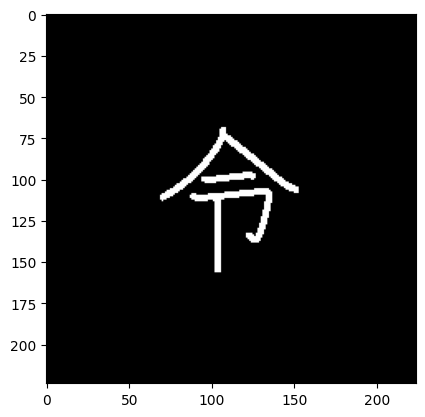

<Figure size 200x200 with 0 Axes>

In [ ]:
tensor = preprocess("../data/jouyou/0f9a8.png")  # or any sample
img = tensor.squeeze(0).permute(1, 2, 0).numpy()
img = (img * 0.5 + 0.5).clip(0, 1)  # unnormalize back to [0,1] for viewing
plt.imshow(img)
plt.figure(figsize=(2, 2), dpi=100, facecolor='black')
plt.show()

In [ ]:
import numpy as np
import os
from tqdm import tqdm

data_dir = "../data/jouyou"
output_path = "./patch_features_memmap.npy"

# Constants
num_images = len([f for f in os.listdir(data_dir) if f.endswith(".png")])
patches_per_image = 196     # 224x224 image with 16x16 patches
feature_dim = 384           # ViT-Small hidden dim

# Create a memory-mapped file
patch_features = np.memmap(output_path, dtype='float32', mode='w+',
                           shape=(num_images * patches_per_image, feature_dim))

print("Memmap file initialized:", patch_features.shape)

index = 0
for fname in tqdm(os.listdir(data_dir)):
    if not fname.endswith(".png"):
        continue

    try:
        img_tensor = preprocess(os.path.join(data_dir, fname))
        with torch.no_grad():
            feats = extract_patch_features(model, img_tensor)  # shape: (196, 384)

        patch_features[index:index + patches_per_image] = feats
        index += patches_per_image

    except Exception as e:
        print(f"Failed on {fname}: {e}")
        continue

# Flush memmap to disk
patch_features.flush()
print("Done. Features saved to", output_path)

Memmap file initialized: (2284968, 384)


100%|██████████| 11658/11658 [13:45<00:00, 14.13it/s]

Done. Features saved to ./patch_features_memmap.npy


In [37]:
import numpy as np

# Adjust these based on your actual dataset
num_images = 2136
patches_per_image = 196
feature_dim = 384

features = np.memmap("patch_features_memmap.npy", dtype='float32', mode='r',
                     shape=(num_images * patches_per_image, feature_dim))


In [38]:
from sklearn.cluster import KMeans

num_clusters = 300  # Try 50, 100, or 200 — experiment

kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(features)

print("Clustering done. Cluster labels shape:", cluster_labels.shape)


Clustering done. Cluster labels shape: (418656,)


In [39]:
from PIL import Image
import matplotlib.pyplot as plt

def load_and_crop_patch(image_path, patch_index, patch_size=16):
    row = patch_index // 14
    col = patch_index % 14

    img = Image.open(image_path).convert('RGB').resize((224, 224))
    patch = img.crop((
        col * patch_size,
        row * patch_size,
        (col + 1) * patch_size,
        (row + 1) * patch_size
    ))
    return patch

100%|██████████| 11658/11658 [00:00<00:00, 37132.31it/s]


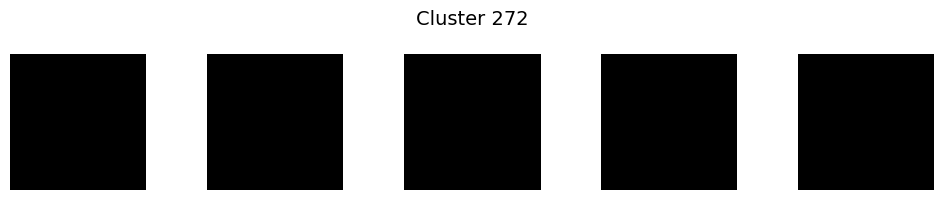

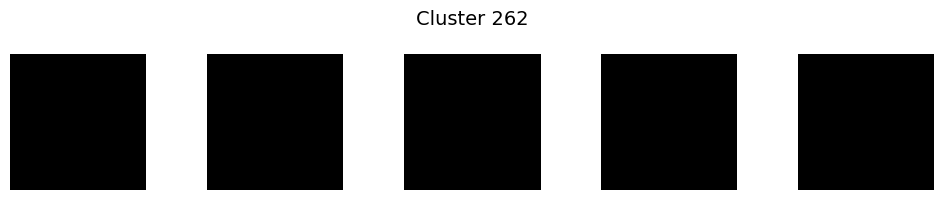

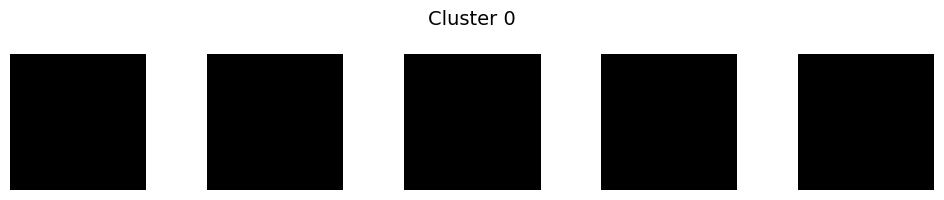

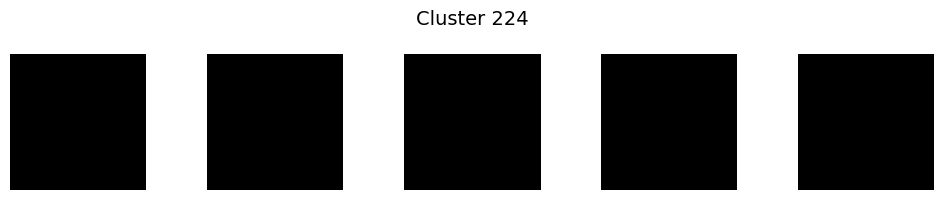

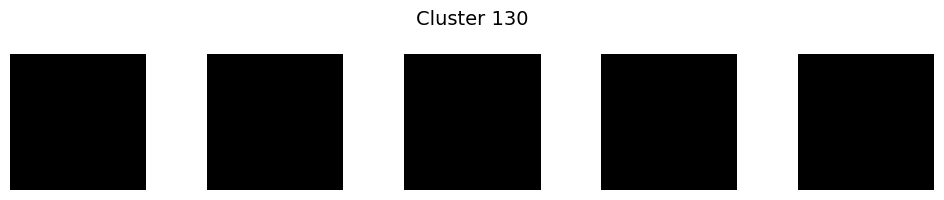

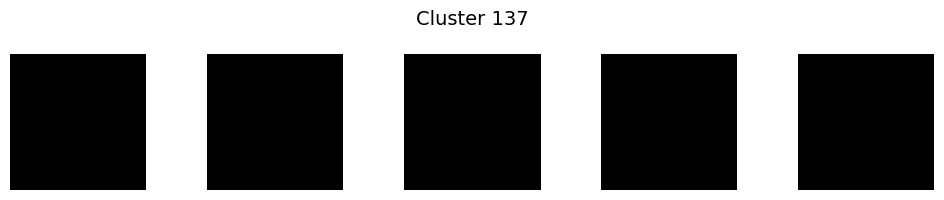

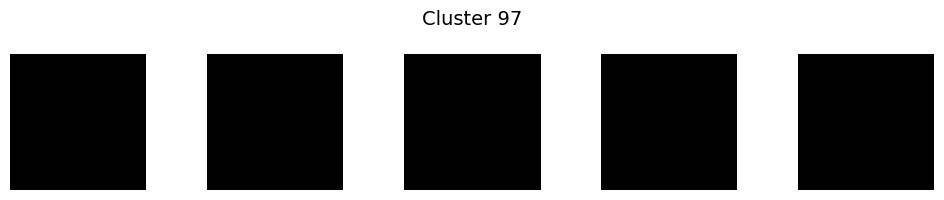

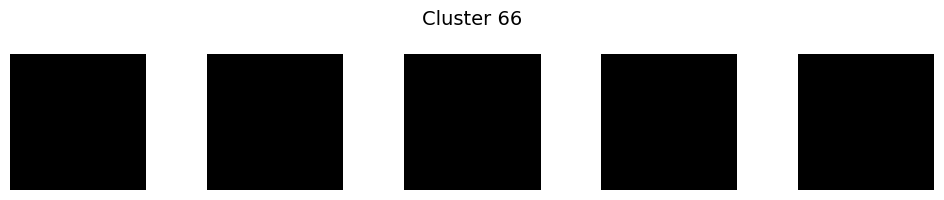

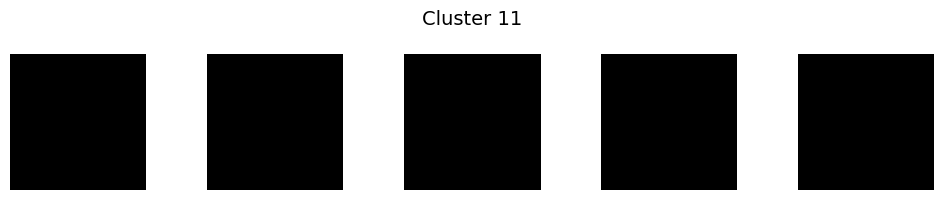

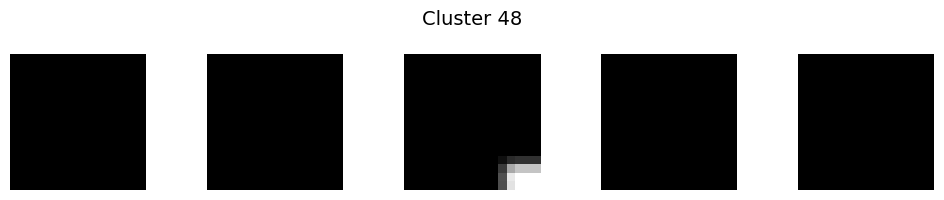

In [ ]:
from collections import defaultdict
from tqdm import tqdm

data_dir = "../data/jouyou"
# Only use the images you actually extracted features from
image_files = sorted(os.listdir("../data/jouyou"))
data_dir = "../data/jouyou"

patches_by_cluster = defaultdict(list)

# Collect example (image, patch_id) per cluster
for img_idx, fname in enumerate(tqdm(image_files)):
    for patch_id in range(patches_per_image):
        index = img_idx * patches_per_image + patch_id
        if index >= len(cluster_labels):
            continue
        cluster_id = cluster_labels[index]


        if len(patches_by_cluster[cluster_id]) < 5:
            patches_by_cluster[cluster_id].append((os.path.join(data_dir, fname), patch_id))

# Visualize top clusters
for cluster_id, samples in list(patches_by_cluster.items())[:10]:  # view first 10 clusters
    fig, axs = plt.subplots(1, len(samples), figsize=(len(samples)*2, 2))
    fig.suptitle(f"Cluster {cluster_id}", fontsize=14)

    for ax, (img_path, patch_idx) in zip(axs, samples):
        patch = load_and_crop_patch(img_path, patch_idx)
        ax.imshow(patch)
        ax.axis('off')

    plt.tight_layout()
    plt.show()